# FeCoNiCrV K/CTE Optimization: Three-Way Comparison

**Objective:** Maximize K / |CTE| ratio

**Strategies:**
1. Pure QEHVI (Full Exploitation)
2. Pure MESMO (Full Exploration)
3. LLM Agent-Driven BO (Adaptive)

This notebook runs all three strategies and compares their performance.

## Cell 1: Imports and Global Setup

In [1]:
import os
import gc
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple

import sys
sys.path.append(".")

from dotenv import load_dotenv
load_dotenv()

from core.design_space import DesignSpace
from core.truth_interface import TruthModelEvaluator
from core.gp_models import GPModelManager
from core.acquisition_functions import AcquisitionFunctionManager
from core.agent_manager import BOAgent, ResourceEvent
from core.fixed_policy import PureQEHVI, PureMESMO
from core.logging_utils import LoggingManager
from core.visualization import VisualizationManager

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.double

print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Device: cuda
PyTorch version: 2.8.0+cu128


## Cell 2: Problem Configuration (FeCoNiCrV)

In [2]:
# Design space: 5D Fe-Co-Ni-Cr-V simplex
COMPONENTS = [
    ("Fe", 0.10, 0.40),
    ("Co", 0.10, 0.40),
    ("Ni", 0.10, 0.40),
    ("Cr", 0.10, 0.40),
    ("V",  0.10, 0.40),
]
STEP = 0.025
SEED = 256

design_space = DesignSpace(components=COMPONENTS, step=STEP, seed=SEED)
bounds_np = design_space.get_bounds()  # (2, 5)
bounds_t = torch.tensor(bounds_np, dtype=DTYPE, device=DEVICE)

print(f"\nDesign space created with {len(design_space.space)} valid compositions")

# Truth model paths (RF + scalers)
MODEL_PATH = "ground_truth_models/FeCoNiCrV_Min_CTE_Max_K/models/RFR_best_model.pkl"
X_SCALER_PATH = "ground_truth_models/FeCoNiCrV_Min_CTE_Max_K/models/x_scaler.pkl"
Y_SCALER_PATH = "ground_truth_models/FeCoNiCrV_Min_CTE_Max_K/models/y_scaler.pkl"

def postprocess_outputs(preds_raw: np.ndarray) -> np.ndarray:
    """
    RF output (based on TARGET_COLS order):
      preds_raw[:,0] = CTE_micro (x 10^(-6) 1/K)
      preds_raw[:,1] = K (W/mK)
    
    We want:
      Y[:,0] = |CTE| (absolute value)
      Y[:,1] = K
    """
    cte_micro = preds_raw[:, 0]  # CTE is at index 0
    k = preds_raw[:, 1]           # K is at index 1
    cte = np.abs(cte_micro)
    return np.column_stack([cte, k])

evaluator = TruthModelEvaluator(
    model_path=MODEL_PATH,
    x_scaler_path=X_SCALER_PATH,
    y_scaler_path=Y_SCALER_PATH,
    postprocess_outputs=postprocess_outputs,
)

# Objective names
OBJ1_NAME = "CTE"  # Y[:,0]
OBJ2_NAME = "K"    # Y[:,1]

# Score function: maximize K / |CTE|
def score_fn(Y: np.ndarray) -> np.ndarray:
    cte = Y[:, 0]  # |CTE|
    k = Y[:, 1]    # K
    return k / (np.abs(cte) + 1e-12)

SCORE_NAME = "K / |CTE|"

print(f"\nObjectives: {OBJ1_NAME}, {OBJ2_NAME}")
print(f"Score metric: {SCORE_NAME}")

[DesignSpace] Generated 8976 valid compositions for 5 components: Fe, Co, Ni, Cr, V

Design space created with 8976 valid compositions
[TruthEvaluator] Loading model from ground_truth_models/FeCoNiCrV_Min_CTE_Max_K/models/RFR_best_model.pkl
[TruthEvaluator] Model loaded successfully
[TruthEvaluator] RF outputs: 2

Objectives: CTE, K
Score metric: K / |CTE|


## Cell 3: BO Configuration

In [3]:
# BO parameters
INIT_N = 5             # Initial random samples
ITERS = 2              # BO iterations
MC_SAMPLES = 128        # Monte Carlo samples for acquisition
POOL_SUBSAMPLE = 1000   # Subsample pool size (None = use full space)
TOTAL_BATCH_SIZE = 5    # Points per iteration

# Resource constraints (for LLM agent)
TOTAL_BUDGET = 10000.0    # $ total budget
TOTAL_TIME = 20.0         # weeks total time
COST_PER_POINT = 100.0    # $ per experiment
TIME_PER_ITERATION = 1.0  # weeks per iteration

# LLM agent configuration
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
AGENT_MODEL = "gpt-4o"
AGENT_TEMPERATURE = 0.7
MAX_REASONING_STEPS = 5

PROBLEM_DESCRIPTION = """
High Entropy Alloy (HEA) optimization in the Fe-Co-Ni-Cr-V composition space.

Objectives:
- Minimize CTE (Coefficient of Thermal Expansion)
- Maximize K (Thermal Conductivity)

Goal: Maximize K / |CTE| ratio

Input space: 5D compositions (Fe, Co, Ni, Cr, V), each in [0.1, 0.4], summing to 1.0.

You should balance exploration and exploitation given the qEHVI and MO-MESMO 
acquisition values for each option to best reach the goal within budget and time constraints.
"""

# Output configuration
OUTPUT_DIR = "results/FeCoNiCrV_K_CTE_Comparison"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CREATE_VIS = True   # Create visualizations (pentagon plots for 5D)
CREATE_GIF = True   # Create animated GIFs

print(f"\nBO Configuration:")
print(f"  Initial samples: {INIT_N}")
print(f"  Iterations: {ITERS}")
print(f"  Batch size: {TOTAL_BATCH_SIZE}")
print(f"  Total evaluations: {INIT_N + ITERS * TOTAL_BATCH_SIZE}")
print(f"\nOutput directory: {OUTPUT_DIR}")


BO Configuration:
  Initial samples: 5
  Iterations: 2
  Batch size: 5
  Total evaluations: 15

Output directory: results/FeCoNiCrV_K_CTE_Comparison


## Cell 4: Helper Function - Run BO Experiment

In [4]:
def run_bo_experiment(
    experiment_name: str,
    strategy,  # Can be PureQEHVI, PureMESMO, or BOAgent
    seed: int = SEED,
    create_visualization: bool = CREATE_VIS,
) -> Tuple[np.ndarray, np.ndarray, LoggingManager]:
    """
    Run a single BO experiment with a given strategy.
    
    OPTIMIZED: Only computes necessary allocation options:
    - PureQEHVI: Only option 0 (all exploitation)
    - PureMESMO: Only option 5 (all exploration)
    - BOAgent: All 6 options (adaptive selection)
    
    Returns:
        X_history: (n, 5) final input history
        Y_history: (n, 2) final output history
        logger: LoggingManager instance
    """
    print(f"\n{'='*80}")
    print(f"[Experiment] {experiment_name}")
    print(f"[Strategy] {type(strategy).__name__}")
    print(f"{'='*80}")
    
    # Set seeds
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # Setup managers
    gp_manager = GPModelManager(bounds=bounds_t)
    acq_manager = AcquisitionFunctionManager(
        bounds=bounds_t,
    )
    
    # Setup logging
    exp_dir = os.path.join(OUTPUT_DIR, experiment_name)
    os.makedirs(exp_dir, exist_ok=True)
    logger = LoggingManager(exp_dir, experiment_name)
    
    # Setup visualization (pentagon plot for 5D)
    vis_manager = None
    if create_visualization:
        vis_manager = VisualizationManager(
            design_space=design_space,
            log_dir=exp_dir,
            experiment_name=experiment_name,
        )
    
    # Initial sampling
    print(f"\n[Init] Sampling {INIT_N} initial points...")
    X0_np = design_space.sample(INIT_N, method="random")
    result0 = evaluator.evaluate(X0_np)
    Y0_np = result0.y
    
    X = torch.tensor(X0_np, dtype=DTYPE, device=DEVICE)
    Y = torch.tensor(Y0_np, dtype=DTYPE, device=DEVICE)
    
    # Log iteration 0
    logger.log_iteration(
        iteration=0,
        X_history=X.cpu().numpy(),
        Y_history=Y.cpu().numpy(),
        n_new_points=INIT_N,
        strategy=strategy,
        timing=0.0,
        extra_info={"experiment": experiment_name},
        acquisition_data=None,
        score_fn=score_fn,
        obj1_name=OBJ1_NAME,
        obj2_name=OBJ2_NAME,
    )
    
    logger.log_evaluations(
        iteration=0,
        X_new=X0_np,
        Y_new=Y0_np,
        score_fn=score_fn,
        obj1_name=OBJ1_NAME,
        obj2_name=OBJ2_NAME,
    )
    
    # Compute initial best score
    scores = score_fn(Y.cpu().numpy())
    best_score = float(np.max(scores))
    print(f"[Init] Best {SCORE_NAME}: {best_score:.4f}")
    
    # Resource tracking (for agent)
    budget_remaining = TOTAL_BUDGET - (INIT_N * COST_PER_POINT)
    time_remaining = TOTAL_TIME - TIME_PER_ITERATION
    
    # Main BO loop
    for iteration in range(1, ITERS + 1):
        iter_start = time.perf_counter()
        print(f"\n[Iter {iteration}/{ITERS}] Starting...")
        
        # Fit GP model
        model = gp_manager.fit_model(X, Y)
        
        # Compute Pareto front (negate first objective to maximize both)
        Y_np = Y.cpu().numpy()
        Y_for_pareto = torch.tensor(
            np.column_stack([-Y_np[:, 0], Y_np[:, 1]]),
            dtype=DTYPE,
            device=DEVICE,
        )
        pareto_Y, ref_point = acq_manager.compute_pareto_front(Y_for_pareto)
        
        # Sample candidate pool
        if POOL_SUBSAMPLE is not None:
            X_pool_np = design_space.sample(POOL_SUBSAMPLE, method="sobol")
        else:
            X_pool_np = design_space.space.copy()
        X_pool = torch.tensor(X_pool_np, dtype=DTYPE, device=DEVICE)
        
        # ============================================================
        # OPTIMIZED: Compute only necessary allocation options
        # ============================================================
        if isinstance(strategy, PureQEHVI):
            # Pure QEHVI only needs option 0 (all exploitation)
            print("[Strategy] Pure QEHVI - Computing option 0 only (5 exploit, 0 explore)")
            allocation_options = acq_manager.compute_single_allocation_option(
                model=model,
                X_pool=X_pool,
                pareto_Y=pareto_Y,
                ref_point=ref_point,
                mc_samples=MC_SAMPLES,
                n_optimization=TOTAL_BATCH_SIZE,
                n_exploration=0,
            )
        elif isinstance(strategy, PureMESMO):
            # Pure MESMO only needs option 5 (all exploration)
            print("[Strategy] Pure MESMO - Computing option 5 only (0 exploit, 5 explore)")
            allocation_options = acq_manager.compute_single_allocation_option(
                model=model,
                X_pool=X_pool,
                pareto_Y=pareto_Y,
                ref_point=ref_point,
                mc_samples=MC_SAMPLES,
                n_optimization=0,
                n_exploration=TOTAL_BATCH_SIZE,
            )
        else:
            # LLM agent needs all 6 options for adaptive selection
            print("[Strategy] LLM Agent - Computing all 6 allocation options")
            allocation_options = acq_manager.compute_all_allocation_options(
                model=model,
                X_pool=X_pool,
                pareto_Y=pareto_Y,
                ref_point=ref_point,
                mc_samples=MC_SAMPLES,
            )
        
        # Select points based on strategy
        if isinstance(strategy, BOAgent):
            # LLM agent selection
            selected_idx, reasoning, selected_point_arrays = strategy.select_resource_allocation(
                iteration=iteration,
                budget_remaining=budget_remaining,
                time_remaining=time_remaining,
                cost_per_point=COST_PER_POINT,
                time_per_point=TIME_PER_ITERATION,
                X_history=X.cpu().numpy(),
                Y_history=Y.cpu().numpy(),
                allocation_options=allocation_options,
                max_batch_size=TOTAL_BATCH_SIZE,
                score_fn=score_fn,
            )
            
            if selected_point_arrays:
                X_next_np = np.vstack(selected_point_arrays)
            else:
                # Fallback to balanced option
                print("[Warning] Agent selected no points; using balanced fallback")
                batch = allocation_options.qehvi_batches[2]
                parts = []
                if batch.points.size > 0:
                    parts.append(batch.points)
                if batch.explore_points.size > 0:
                    parts.append(batch.explore_points)
                X_next_np = np.vstack(parts) if parts else design_space.sample(1, method="random")
            
            extra_info = {
                "agent_selected_option": selected_idx,
                "agent_reasoning": reasoning[:200] + "..." if len(reasoning) > 200 else reasoning,
                "budget_remaining": budget_remaining,
                "time_remaining": time_remaining,
            }
        else:
            # Fixed policy selection (PureQEHVI or PureMESMO)
            X_next_np, reasoning = strategy.select_points(allocation_options)
            extra_info = {
                "policy": type(strategy).__name__,
                "reasoning": reasoning,
            }
        
        # Evaluate selected points
        result_next = evaluator.evaluate(X_next_np)
        Y_next_np = result_next.y
        
        # Update history
        X = torch.cat([X, torch.tensor(X_next_np, dtype=DTYPE, device=DEVICE)], dim=0)
        Y = torch.cat([Y, torch.tensor(Y_next_np, dtype=DTYPE, device=DEVICE)], dim=0)
        
        # Update resources
        points_used = len(X_next_np)
        budget_spent = points_used * COST_PER_POINT
        time_spent = TIME_PER_ITERATION
        budget_remaining -= budget_spent
        time_remaining -= time_spent
        
        iter_time = time.perf_counter() - iter_start
        
        # Logging
        logger.log_iteration(
            iteration=iteration,
            X_history=X.cpu().numpy(),
            Y_history=Y.cpu().numpy(),
            n_new_points=points_used,
            strategy=strategy,
            timing=iter_time,
            extra_info=extra_info,
            acquisition_data=allocation_options,
            score_fn=score_fn,
            obj1_name=OBJ1_NAME,
            obj2_name=OBJ2_NAME,
        )
        
        logger.log_evaluations(
            iteration=iteration,
            X_new=X_next_np,
            Y_new=Y_next_np,
            score_fn=score_fn,
            obj1_name=OBJ1_NAME,
            obj2_name=OBJ2_NAME,
        )
        
        # Visualization
        if vis_manager is not None:
            vis_manager.create_iteration_plot(
                iteration=iteration,
                X_history=X.cpu().numpy(),
                Y_history=Y.cpu().numpy(),
                X_new=X_next_np,
                model=model,
                bounds=bounds_t,
                selection_info=extra_info,
                score_fn=score_fn,
                score_name=SCORE_NAME,
                obj1_name=OBJ1_NAME,
                obj2_name=OBJ2_NAME,
            )
        
        # Print progress
        scores = score_fn(Y.cpu().numpy())
        best_score = float(np.max(scores))
        mean_score = float(np.mean(scores))
        
        print(f"[Iter {iteration}] Complete in {iter_time:.2f}s")
        print(f"  Best {SCORE_NAME}: {best_score:.4f}")
        print(f"  Mean {SCORE_NAME}: {mean_score:.4f}")
        print(f"  Points evaluated: {points_used}")
        
        # Cleanup
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    # Finalize
    logger.finalize()
    
    # Create GIF if requested
    if vis_manager is not None and CREATE_GIF:
        vis_manager.create_gif(duration=2.0, gif_name=f"{experiment_name}.gif")
    
    # Save agent memory if applicable
    if isinstance(strategy, BOAgent):
        strategy.save_global_memory()
    
    # Final summary
    X_final = X.cpu().numpy()
    Y_final = Y.cpu().numpy()
    scores_final = score_fn(Y_final)
    
    print(f"\n[{experiment_name}] Experiment complete!")
    print(f"  Total evaluations: {len(X_final)}")
    print(f"  Best {SCORE_NAME}: {np.max(scores_final):.4f}")
    print(f"  Mean {SCORE_NAME}: {np.mean(scores_final):.4f}")
    print(f"  Std {SCORE_NAME}: {np.std(scores_final):.4f}")
    
    return X_final, Y_final, logger

## Cell 5: Run Pure QEHVI

In [5]:
# Run Pure QEHVI experiment
strategy_qehvi = PureQEHVI()

X_qehvi, Y_qehvi, logger_qehvi = run_bo_experiment(
    experiment_name="pure_qehvi",
    strategy=strategy_qehvi,
    seed=SEED,
    create_visualization=CREATE_VIS,
)


[Experiment] pure_qehvi
[Strategy] PureQEHVI
[Logger] Initialized logging in results/FeCoNiCrV_K_CTE_Comparison\pure_qehvi
[Logger] Files:
  - Convergence: results/FeCoNiCrV_K_CTE_Comparison\pure_qehvi\pure_qehvi_convergence.csv
  - Options: results/FeCoNiCrV_K_CTE_Comparison\pure_qehvi\pure_qehvi_options.csv
  - Evaluations: results/FeCoNiCrV_K_CTE_Comparison\pure_qehvi\pure_qehvi_evaluations.csv
[Viz] Using full design space (8976 points) for visualization
[Viz] Setup affine projection: projected 8976 points
[Viz] Cached visualization space on CPU: torch.Size([8976, 5])
[Viz] Initialized visualization in results/FeCoNiCrV_K_CTE_Comparison\pure_qehvi\visualizations
[Viz] Experiment name: pure_qehvi
[Viz] Dimension d=5, labels=['Fe', 'Co', 'Ni', 'Cr', 'V']

[Init] Sampling 5 initial points...
[Logger] Logged convergence for iteration 0
[Logger] Logged 5 evaluations for iteration 0
[Init] Best K / |CTE|: 0.9452

[Iter 1/2] Starting...


c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\linear_operator\utils\interpolation.py:71: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\tensor\python_tensor.cpp:80.)
  summing_matrix = cls(summing_matrix_indices, summing_matrix_values, size)
c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\linear_operator\utils\interpolation.py:71: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at C:\actions-runner\_wor

[Strategy] Pure QEHVI - Computing option 0 only (5 exploit, 0 explore)
[AcqFn] Computing single allocation: 5 exploit + 0 explore
  Optimizing qEHVI with q=5...
  Optimizing qEHVI with q=5...
  → Entropy: 23.3864, QEHVI: 6.3188
[Logger] Logged convergence for iteration 1
[Logger] Logged 1 options with 5 total points for iteration 1
[Logger] Logged 5 evaluations for iteration 1
[Viz] Predicted scores - Min: -0.1032, Max: 1.0877, Mean: 0.5028


c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Viz] Created plot for iteration 1
[Iter 1] Complete in 21.38s
  Best K / |CTE|: 7.2737
  Mean K / |CTE|: 1.3126
  Points evaluated: 5

[Iter 2/2] Starting...
[Strategy] Pure QEHVI - Computing option 0 only (5 exploit, 0 explore)
[AcqFn] Computing single allocation: 5 exploit + 0 explore
  Optimizing qEHVI with q=5...
  Optimizing qEHVI with q=5...
  → Entropy: 24.0278, QEHVI: 3.5294
[Logger] Logged convergence for iteration 2
[Logger] Logged 1 options with 5 total points for iteration 2
[Logger] Logged 5 evaluations for iteration 2
[Viz] Predicted scores - Min: -0.6493, Max: 7.2735, Mean: 1.1321


c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Viz] Created plot for iteration 2
[Iter 2] Complete in 19.42s
  Best K / |CTE|: 7.2737
  Mean K / |CTE|: 1.4966
  Points evaluated: 5
[Logger] Finalized logging for pure_qehvi
[Viz] Determining minimum image dimensions for GIF...
[Viz] Created GIF at results/FeCoNiCrV_K_CTE_Comparison\pure_qehvi\pure_qehvi.gif

[pure_qehvi] Experiment complete!
  Total evaluations: 15
  Best K / |CTE|: 7.2737
  Mean K / |CTE|: 1.4966
  Std K / |CTE|: 2.1290


## Cell 6: Run Pure MESMO

In [6]:
# Run Pure MESMO experiment
strategy_mesmo = PureMESMO()

X_mesmo, Y_mesmo, logger_mesmo = run_bo_experiment(
    experiment_name="pure_mesmo",
    strategy=strategy_mesmo,
    seed=SEED,
    create_visualization=CREATE_VIS,
)


[Experiment] pure_mesmo
[Strategy] PureMESMO
[Logger] Initialized logging in results/FeCoNiCrV_K_CTE_Comparison\pure_mesmo
[Logger] Files:
  - Convergence: results/FeCoNiCrV_K_CTE_Comparison\pure_mesmo\pure_mesmo_convergence.csv
  - Options: results/FeCoNiCrV_K_CTE_Comparison\pure_mesmo\pure_mesmo_options.csv
  - Evaluations: results/FeCoNiCrV_K_CTE_Comparison\pure_mesmo\pure_mesmo_evaluations.csv
[Viz] Using full design space (8976 points) for visualization
[Viz] Setup affine projection: projected 8976 points
[Viz] Cached visualization space on CPU: torch.Size([8976, 5])
[Viz] Initialized visualization in results/FeCoNiCrV_K_CTE_Comparison\pure_mesmo\visualizations
[Viz] Experiment name: pure_mesmo
[Viz] Dimension d=5, labels=['Fe', 'Co', 'Ni', 'Cr', 'V']

[Init] Sampling 5 initial points...
[Logger] Logged convergence for iteration 0
[Logger] Logged 5 evaluations for iteration 0
[Init] Best K / |CTE|: 0.8854

[Iter 1/2] Starting...


c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Strategy] Pure MESMO - Computing option 5 only (0 exploit, 5 explore)
[AcqFn] Computing single allocation: 0 exploit + 5 explore
  Optimizing MO-MESMO with q=5...
  Optimizing MO-MESMO with q=5...
  ✓ MO-MESMO succeeded
  → Entropy: 8.0152, QEHVI: 5.9108
[Logger] Logged convergence for iteration 1
[Logger] Logged 1 options with 5 total points for iteration 1
[Logger] Logged 5 evaluations for iteration 1
[Viz] Predicted scores - Min: -0.4095, Max: 1.1455, Mean: 0.4383


c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Viz] Created plot for iteration 1
[Iter 1] Complete in 23.16s
  Best K / |CTE|: 1.7792
  Mean K / |CTE|: 0.5107
  Points evaluated: 5

[Iter 2/2] Starting...
[Strategy] Pure MESMO - Computing option 5 only (0 exploit, 5 explore)
[AcqFn] Computing single allocation: 0 exploit + 5 explore
  Optimizing MO-MESMO with q=5...
  Optimizing MO-MESMO with q=5...
  ✓ MO-MESMO succeeded
  → Entropy: -7.0188, QEHVI: 6.7514
[Logger] Logged convergence for iteration 2
[Logger] Logged 1 options with 5 total points for iteration 2
[Logger] Logged 5 evaluations for iteration 2
[Viz] Predicted scores - Min: -0.0399, Max: 1.8009, Mean: 0.5283


c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Viz] Created plot for iteration 2
[Iter 2] Complete in 36.45s
  Best K / |CTE|: 1.7792
  Mean K / |CTE|: 0.4751
  Points evaluated: 5
[Logger] Finalized logging for pure_mesmo
[Viz] Determining minimum image dimensions for GIF...
[Viz] Created GIF at results/FeCoNiCrV_K_CTE_Comparison\pure_mesmo\pure_mesmo.gif

[pure_mesmo] Experiment complete!
  Total evaluations: 15
  Best K / |CTE|: 1.7792
  Mean K / |CTE|: 0.4751
  Std K / |CTE|: 0.6021


## Cell 7: Run LLM Agent-Driven BO

In [7]:
# Setup LLM agent
if OPENAI_API_KEY is None:
    raise ValueError("OPENAI_API_KEY environment variable not set!")

agent_log_dir = os.path.join(OUTPUT_DIR, "llm_agent", "agent_logs")
os.makedirs(agent_log_dir, exist_ok=True)

strategy_agent = BOAgent(
    model=AGENT_MODEL,
    temperature=AGENT_TEMPERATURE,
    api_key=OPENAI_API_KEY,
    log_dir=agent_log_dir,
    problem_description=PROBLEM_DESCRIPTION,
    obj1_name=OBJ1_NAME,
    obj2_name=OBJ2_NAME,
)

# Run LLM agent experiment
X_agent, Y_agent, logger_agent = run_bo_experiment(
    experiment_name="llm_agent",
    strategy=strategy_agent,
    seed=SEED,
    create_visualization=CREATE_VIS,
)


[Experiment] llm_agent
[Strategy] BOAgent
[Logger] Initialized logging in results/FeCoNiCrV_K_CTE_Comparison\llm_agent
[Logger] Files:
  - Convergence: results/FeCoNiCrV_K_CTE_Comparison\llm_agent\llm_agent_convergence.csv
  - Options: results/FeCoNiCrV_K_CTE_Comparison\llm_agent\llm_agent_options.csv
  - Evaluations: results/FeCoNiCrV_K_CTE_Comparison\llm_agent\llm_agent_evaluations.csv
[Viz] Using full design space (8976 points) for visualization
[Viz] Setup affine projection: projected 8976 points
[Viz] Cached visualization space on CPU: torch.Size([8976, 5])
[Viz] Initialized visualization in results/FeCoNiCrV_K_CTE_Comparison\llm_agent\visualizations
[Viz] Experiment name: llm_agent
[Viz] Dimension d=5, labels=['Fe', 'Co', 'Ni', 'Cr', 'V']

[Init] Sampling 5 initial points...
[Logger] Logged convergence for iteration 0
[Logger] Logged 5 evaluations for iteration 0
[Init] Best K / |CTE|: 0.8292

[Iter 1/2] Starting...


c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Strategy] LLM Agent - Computing all 6 allocation options
[AcqFn] Computing acquisition functions.
[AcqFn] Using 128 samples for qEHVI, 128 for MO-MESMO
[AcqFn] Computing top entropy reference points...

[AcqFn] Option 0: 5 exploit + 0 explore
  Optimizing qEHVI with q=5...
  → Entropy: 22.5702, QEHVI: 5.9440

[AcqFn] Option 1: 4 exploit + 1 explore
  Optimizing qEHVI with q=4...
  Optimizing MO-MESMO with q=1...
  ✓ MO-MESMO succeeded
  → Entropy: 18.0563, QEHVI: 5.9267

[AcqFn] Option 2: 3 exploit + 2 explore
  Optimizing qEHVI with q=3...
  Optimizing MO-MESMO with q=2...
  ✓ MO-MESMO succeeded
  → Entropy: 13.1769, QEHVI: 5.8794

[AcqFn] Option 3: 2 exploit + 3 explore
  Optimizing qEHVI with q=2...
  Optimizing MO-MESMO with q=3...
  ✓ MO-MESMO succeeded
  → Entropy: 8.3721, QEHVI: 5.8237

[AcqFn] Option 4: 1 exploit + 4 explore
  Optimizing qEHVI with q=1...
  Optimizing MO-MESMO with q=4...
  ✓ MO-MESMO succeeded
  → Entropy: 7.1869, QEHVI: 5.7891

[AcqFn] Option 5: 0 exploit + 

c:\Users\shakt\Documents\gitrepo\resource-allocation\core\agent_manager.py:197: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  return ConversationBufferMemory(memory_key="chat_history", return_messages=True)


[Agent:INFO] 
1. **Runway Assessment**: With a budget for approximately 95 points and 19 iterations, we have a relatively comfortable runway. This allows us to balance exploration and exploitation effectively, focusing initially on refining our understanding of the landscape.

2. **Progress Momentum**: As this is iteration 1, we don't have a trend or a strong sense of progress momentum. Therefore, it's reasonable to infer that we should start with a balanced approach to gather more information about the input space.

3. **Best Observed Point**: The best observed point has a CTE of 11.15 and K of 9.248. While this provides a baseline, it doesn't give us enough information to decide if we should exploit heavily.

4. **Allocation Options**: 
   - **Option 0 (5 exploit, 0 explore)** has the highest EHVI but the highest entropy, suggesting a lack of exploration.
   - **Option 1 (4 exploit, 1 explore)** offers a slightly lower EHVI but reduces entropy, indicating some exploration.
   - **Opt

c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Viz] Created plot for iteration 1
[Iter 1] Complete in 94.51s
  Best K / |CTE|: 1.1766
  Mean K / |CTE|: 0.7010
  Points evaluated: 5

[Iter 2/2] Starting...
[Strategy] LLM Agent - Computing all 6 allocation options
[AcqFn] Computing acquisition functions.
[AcqFn] Using 128 samples for qEHVI, 128 for MO-MESMO
[AcqFn] Computing top entropy reference points...

[AcqFn] Option 0: 5 exploit + 0 explore
  Optimizing qEHVI with q=5...
  → Entropy: 15.2408, QEHVI: 6.4058

[AcqFn] Option 1: 4 exploit + 1 explore
  Optimizing qEHVI with q=4...
  Optimizing MO-MESMO with q=1...
  ✓ MO-MESMO succeeded
  → Entropy: 8.6088, QEHVI: 6.3791

[AcqFn] Option 2: 3 exploit + 2 explore
  Optimizing qEHVI with q=3...
  Optimizing MO-MESMO with q=2...
  ✓ MO-MESMO succeeded
  → Entropy: 7.1449, QEHVI: 6.3978

[AcqFn] Option 3: 2 exploit + 3 explore
  Optimizing qEHVI with q=2...
  Optimizing MO-MESMO with q=3...
  ✓ MO-MESMO succeeded
  → Entropy: 15.0356, QEHVI: 6.3558

[AcqFn] Option 4: 1 exploit + 4 expl

c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Viz] Created plot for iteration 2
[Iter 2] Complete in 114.80s
  Best K / |CTE|: 1.3966
  Mean K / |CTE|: 0.7130
  Points evaluated: 5
[Logger] Finalized logging for llm_agent
[Viz] Determining minimum image dimensions for GIF...
[Viz] Created GIF at results/FeCoNiCrV_K_CTE_Comparison\llm_agent\llm_agent.gif

[llm_agent] Experiment complete!
  Total evaluations: 15
  Best K / |CTE|: 1.3966
  Mean K / |CTE|: 0.7130
  Std K / |CTE|: 0.3662


## Cell 8: Analyze and Compare Results

In [8]:
print("\n" + "="*80)
print("COMPREHENSIVE RESULTS COMPARISON")
print("="*80)

# Load convergence data
df_qehvi = logger_qehvi.load_convergence_data()
df_mesmo = logger_mesmo.load_convergence_data()
df_agent = logger_agent.load_convergence_data()

# Load evaluation data
eval_qehvi = logger_qehvi.load_evaluations_data()
eval_mesmo = logger_mesmo.load_evaluations_data()
eval_agent = logger_agent.load_evaluations_data()

# Compute final statistics
scores_qehvi = score_fn(Y_qehvi)
scores_mesmo = score_fn(Y_mesmo)
scores_agent = score_fn(Y_agent)

results_summary = {
    "Strategy": ["Pure QEHVI", "Pure MESMO", "LLM Agent"],
    "Best Score": [
        np.max(scores_qehvi),
        np.max(scores_mesmo),
        np.max(scores_agent),
    ],
    "Mean Score": [
        np.mean(scores_qehvi),
        np.mean(scores_mesmo),
        np.mean(scores_agent),
    ],
    "Std Score": [
        np.std(scores_qehvi),
        np.std(scores_mesmo),
        np.std(scores_agent),
    ],
    "Total Evaluations": [
        len(Y_qehvi),
        len(Y_mesmo),
        len(Y_agent),
    ],
}

df_summary = pd.DataFrame(results_summary)
print("\n" + df_summary.to_string(index=False))

# Find iteration where max score was achieved
def find_max_iteration(eval_df, score_fn, obj1_name, obj2_name):
    """Find the iteration where maximum score was first achieved."""
    max_score = -np.inf
    max_iter = 0
    
    for iteration in sorted(eval_df['iteration'].unique()):
        iter_data = eval_df[eval_df['iteration'] == iteration]
        Y_iter = iter_data[[obj1_name, obj2_name]].to_numpy()
        scores_iter = score_fn(Y_iter)
        
        if scores_iter.max() > max_score:
            max_score = scores_iter.max()
            max_iter = iteration
    
    return max_iter, max_score

qehvi_max_iter, qehvi_max_score = find_max_iteration(eval_qehvi, score_fn, OBJ1_NAME, OBJ2_NAME)
mesmo_max_iter, mesmo_max_score = find_max_iteration(eval_mesmo, score_fn, OBJ1_NAME, OBJ2_NAME)
agent_max_iter, agent_max_score = find_max_iteration(eval_agent, score_fn, OBJ1_NAME, OBJ2_NAME)

print("\n" + "="*80)
print("ITERATION WHERE MAX SCORE WAS ACHIEVED")
print("="*80)
print(f"Pure QEHVI: Iteration {qehvi_max_iter} (Score: {qehvi_max_score:.4f})")
print(f"Pure MESMO: Iteration {mesmo_max_iter} (Score: {mesmo_max_score:.4f})")
print(f"LLM Agent:  Iteration {agent_max_iter} (Score: {agent_max_score:.4f})")

# Determine winner
best_overall = max(qehvi_max_score, mesmo_max_score, agent_max_score)
if best_overall == qehvi_max_score:
    winner = "Pure QEHVI"
elif best_overall == mesmo_max_score:
    winner = "Pure MESMO"
else:
    winner = "LLM Agent"

print(f"\n🏆 WINNER: {winner} (Best Score: {best_overall:.4f})")

# Save summary to CSV
summary_path = os.path.join(OUTPUT_DIR, "comparison_summary.csv")
df_summary.to_csv(summary_path, index=False)
print(f"\nSummary saved to: {summary_path}")


COMPREHENSIVE RESULTS COMPARISON

  Strategy  Best Score  Mean Score  Std Score  Total Evaluations
Pure QEHVI    7.273681    1.496561   2.129022                 15
Pure MESMO    1.779183    0.475071   0.602138                 15
 LLM Agent    1.396566    0.713027   0.366225                 15

ITERATION WHERE MAX SCORE WAS ACHIEVED
Pure QEHVI: Iteration 0 (Score: 100.0621)
Pure MESMO: Iteration 0 (Score: 4.7568)
LLM Agent:  Iteration 0 (Score: 4.3294)

🏆 WINNER: Pure QEHVI (Best Score: 100.0621)

Summary saved to: results/FeCoNiCrV_K_CTE_Comparison\comparison_summary.csv


## Cell 9: Plot Convergence Comparison

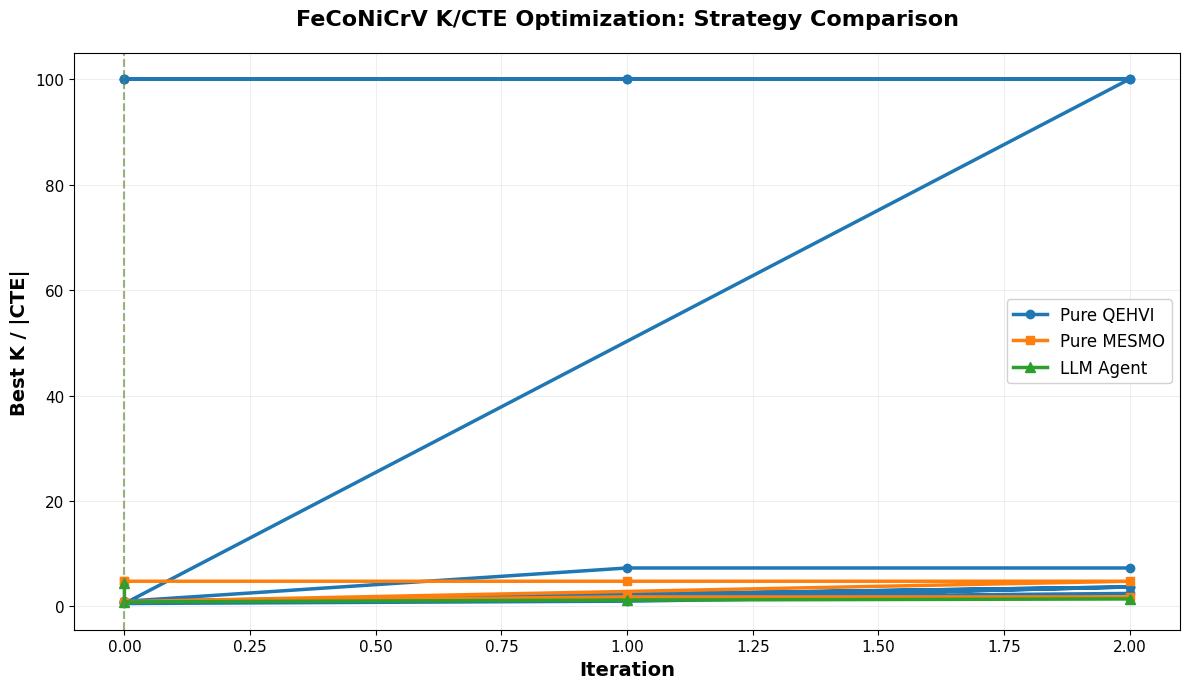

Convergence plot saved to: results/FeCoNiCrV_K_CTE_Comparison\convergence_comparison.png


In [9]:
# Plot best score convergence over iterations
fig, ax = plt.subplots(figsize=(12, 7))

# Plot each strategy
ax.plot(df_qehvi['iteration'], df_qehvi['best_score'], 
        marker='o', linewidth=2.5, label='Pure QEHVI', markersize=6)
ax.plot(df_mesmo['iteration'], df_mesmo['best_score'], 
        marker='s', linewidth=2.5, label='Pure MESMO', markersize=6)
ax.plot(df_agent['iteration'], df_agent['best_score'], 
        marker='^', linewidth=2.5, label='LLM Agent', markersize=7)

# Mark where max was achieved
ax.axvline(x=qehvi_max_iter, color='C0', linestyle='--', alpha=0.3, linewidth=1.5)
ax.axvline(x=mesmo_max_iter, color='C1', linestyle='--', alpha=0.3, linewidth=1.5)
ax.axvline(x=agent_max_iter, color='C2', linestyle='--', alpha=0.3, linewidth=1.5)

ax.set_xlabel('Iteration', fontsize=14, fontweight='bold')
ax.set_ylabel(f'Best {SCORE_NAME}', fontsize=14, fontweight='bold')
ax.set_title('FeCoNiCrV K/CTE Optimization: Strategy Comparison', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.tick_params(labelsize=11)

plt.tight_layout()
convergence_path = os.path.join(OUTPUT_DIR, "convergence_comparison.png")
plt.savefig(convergence_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Convergence plot saved to: {convergence_path}")

## Cell 10: Plot Score Distribution

C:\Users\shakt\AppData\Local\Temp\ipykernel_38760\2344077075.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True,


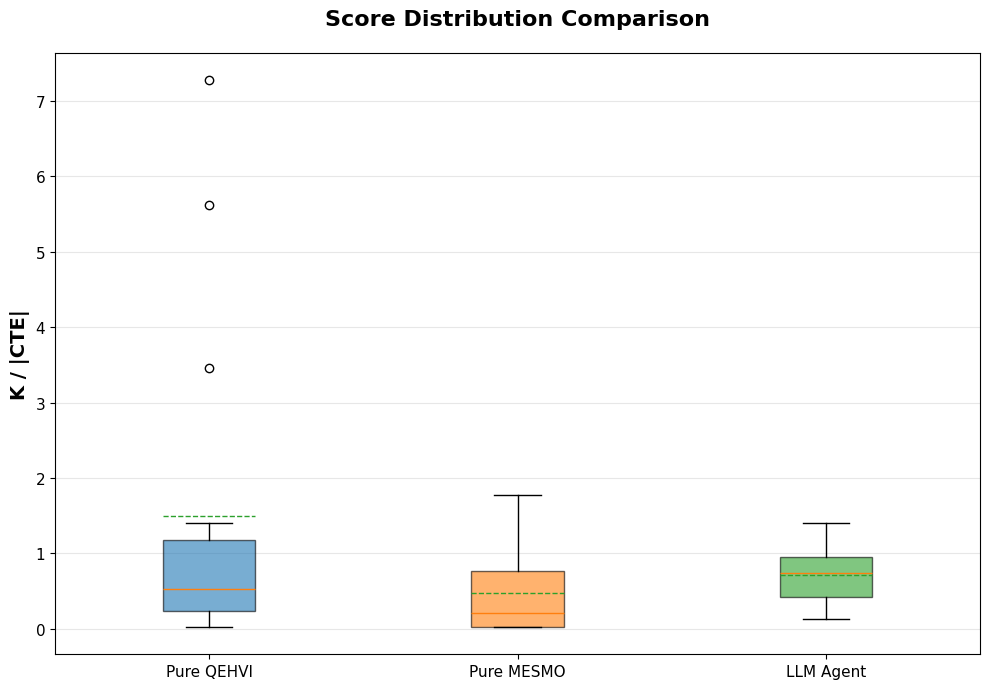

Distribution plot saved to: results/FeCoNiCrV_K_CTE_Comparison\score_distribution.png


In [10]:
# Box plot comparing score distributions
fig, ax = plt.subplots(figsize=(10, 7))

data_to_plot = [scores_qehvi, scores_mesmo, scores_agent]
labels = ['Pure QEHVI', 'Pure MESMO', 'LLM Agent']

bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True,
                showmeans=True, meanline=True)

# Customize colors
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel(f'{SCORE_NAME}', fontsize=14, fontweight='bold')
ax.set_title('Score Distribution Comparison', fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(labelsize=11)

plt.tight_layout()
dist_path = os.path.join(OUTPUT_DIR, "score_distribution.png")
plt.savefig(dist_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Distribution plot saved to: {dist_path}")

## Cell 11: Per-Iteration Best Score Analysis

In [11]:
# Compute cumulative best score per iteration
def compute_cumulative_best(eval_df, score_fn, obj1_name, obj2_name):
    """Compute cumulative best score at each iteration."""
    iterations = sorted(eval_df['iteration'].unique())
    cumulative_best = []
    
    all_scores = []
    for iteration in iterations:
        iter_data = eval_df[eval_df['iteration'] <= iteration]
        Y_so_far = iter_data[[obj1_name, obj2_name]].to_numpy()
        scores_so_far = score_fn(Y_so_far)
        cumulative_best.append(scores_so_far.max())
    
    return iterations, cumulative_best

qehvi_iters, qehvi_cum_best = compute_cumulative_best(eval_qehvi, score_fn, OBJ1_NAME, OBJ2_NAME)
mesmo_iters, mesmo_cum_best = compute_cumulative_best(eval_mesmo, score_fn, OBJ1_NAME, OBJ2_NAME)
agent_iters, agent_cum_best = compute_cumulative_best(eval_agent, score_fn, OBJ1_NAME, OBJ2_NAME)

# Create DataFrame
max_len = max(len(qehvi_iters), len(mesmo_iters), len(agent_iters))
per_iter_df = pd.DataFrame({
    'Iteration': range(max_len),
    'QEHVI_Best': qehvi_cum_best + [np.nan] * (max_len - len(qehvi_cum_best)),
    'MESMO_Best': mesmo_cum_best + [np.nan] * (max_len - len(mesmo_cum_best)),
    'Agent_Best': agent_cum_best + [np.nan] * (max_len - len(agent_cum_best)),
})

print("\nCumulative Best Score per Iteration:")
print(per_iter_df.to_string(index=False))

# Save to CSV
per_iter_path = os.path.join(OUTPUT_DIR, "per_iteration_best_scores.csv")
per_iter_df.to_csv(per_iter_path, index=False)
print(f"\nPer-iteration data saved to: {per_iter_path}")


Cumulative Best Score per Iteration:
 Iteration  QEHVI_Best  MESMO_Best  Agent_Best
         0  100.062055    4.756782    4.329408
         1  100.062055    4.756782    4.329408
         2  100.062055    4.756782    4.329408

Per-iteration data saved to: results/FeCoNiCrV_K_CTE_Comparison\per_iteration_best_scores.csv


## Cell 12: Objective Space Visualization

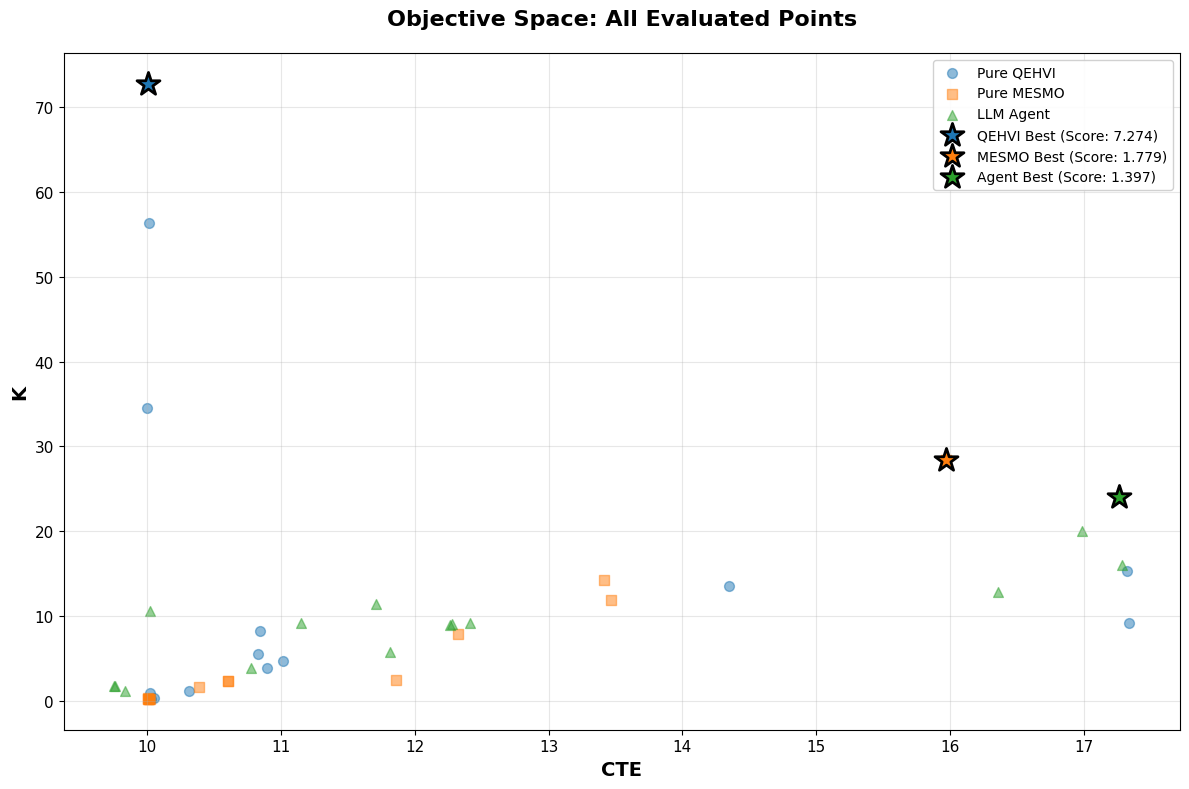

Objective space plot saved to: results/FeCoNiCrV_K_CTE_Comparison\objective_space.png


In [12]:
# Plot all strategies in objective space (CTE vs K)
fig, ax = plt.subplots(figsize=(12, 8))

# Plot evaluated points
ax.scatter(Y_qehvi[:, 0], Y_qehvi[:, 1], alpha=0.5, s=50, 
           label='Pure QEHVI', marker='o')
ax.scatter(Y_mesmo[:, 0], Y_mesmo[:, 1], alpha=0.5, s=50, 
           label='Pure MESMO', marker='s')
ax.scatter(Y_agent[:, 0], Y_agent[:, 1], alpha=0.5, s=50, 
           label='LLM Agent', marker='^')

# Highlight best points
best_idx_qehvi = np.argmax(scores_qehvi)
best_idx_mesmo = np.argmax(scores_mesmo)
best_idx_agent = np.argmax(scores_agent)

ax.scatter(Y_qehvi[best_idx_qehvi, 0], Y_qehvi[best_idx_qehvi, 1], 
           s=300, marker='*', color='C0', edgecolors='black', linewidths=2,
           label=f'QEHVI Best (Score: {scores_qehvi[best_idx_qehvi]:.3f})', zorder=5)
ax.scatter(Y_mesmo[best_idx_mesmo, 0], Y_mesmo[best_idx_mesmo, 1], 
           s=300, marker='*', color='C1', edgecolors='black', linewidths=2,
           label=f'MESMO Best (Score: {scores_mesmo[best_idx_mesmo]:.3f})', zorder=5)
ax.scatter(Y_agent[best_idx_agent, 0], Y_agent[best_idx_agent, 1], 
           s=300, marker='*', color='C2', edgecolors='black', linewidths=2,
           label=f'Agent Best (Score: {scores_agent[best_idx_agent]:.3f})', zorder=5)

ax.set_xlabel(f'{OBJ1_NAME}', fontsize=14, fontweight='bold')
ax.set_ylabel(f'{OBJ2_NAME}', fontsize=14, fontweight='bold')
ax.set_title('Objective Space: All Evaluated Points', fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=10, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=11)

plt.tight_layout()
obj_space_path = os.path.join(OUTPUT_DIR, "objective_space.png")
plt.savefig(obj_space_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Objective space plot saved to: {obj_space_path}")

## Cell 13: Final Summary and Insights

In [13]:
print("\n" + "="*80)
print("FINAL SUMMARY AND INSIGHTS")
print("="*80)

print(f"\n📊 Overall Statistics:")
print(f"  Problem: FeCoNiCrV K/CTE Optimization")
print(f"  Objective: Maximize {SCORE_NAME}")
print(f"  Initial samples: {INIT_N}")
print(f"  BO iterations: {ITERS}")
print(f"  Batch size: {TOTAL_BATCH_SIZE}")
print(f"  Total evaluations per strategy: {INIT_N + ITERS * TOTAL_BATCH_SIZE}")

print(f"\n🏆 Best Results:")
print(f"  Pure QEHVI: {qehvi_max_score:.4f} (achieved at iteration {qehvi_max_iter})")
print(f"  Pure MESMO: {mesmo_max_score:.4f} (achieved at iteration {mesmo_max_iter})")
print(f"  LLM Agent:  {agent_max_score:.4f} (achieved at iteration {agent_max_iter})")

print(f"\n⚡ Convergence Speed:")
fastest_iter = min(qehvi_max_iter, mesmo_max_iter, agent_max_iter)
if fastest_iter == qehvi_max_iter:
    fastest = "Pure QEHVI"
elif fastest_iter == mesmo_max_iter:
    fastest = "Pure MESMO"
else:
    fastest = "LLM Agent"
print(f"  Fastest to achieve best: {fastest} (iteration {fastest_iter})")

print(f"\n📈 Mean Performance:")
print(f"  Pure QEHVI: {np.mean(scores_qehvi):.4f} ± {np.std(scores_qehvi):.4f}")
print(f"  Pure MESMO: {np.mean(scores_mesmo):.4f} ± {np.std(scores_mesmo):.4f}")
print(f"  LLM Agent:  {np.mean(scores_agent):.4f} ± {np.std(scores_agent):.4f}")

print(f"\n🎯 Best Compositions Found:")
print(f"\n  Pure QEHVI (Score: {scores_qehvi[best_idx_qehvi]:.4f}):")
for i, label in enumerate(design_space.labels):
    print(f"    {label}: {X_qehvi[best_idx_qehvi, i]:.3f}")
print(f"    CTE: {Y_qehvi[best_idx_qehvi, 0]:.4f}, K: {Y_qehvi[best_idx_qehvi, 1]:.4f}")

print(f"\n  Pure MESMO (Score: {scores_mesmo[best_idx_mesmo]:.4f}):")
for i, label in enumerate(design_space.labels):
    print(f"    {label}: {X_mesmo[best_idx_mesmo, i]:.3f}")
print(f"    CTE: {Y_mesmo[best_idx_mesmo, 0]:.4f}, K: {Y_mesmo[best_idx_mesmo, 1]:.4f}")

print(f"\n  LLM Agent (Score: {scores_agent[best_idx_agent]:.4f}):")
for i, label in enumerate(design_space.labels):
    print(f"    {label}: {X_agent[best_idx_agent, i]:.3f}")
print(f"    CTE: {Y_agent[best_idx_agent, 0]:.4f}, K: {Y_agent[best_idx_agent, 1]:.4f}")

print(f"\n" + "="*80)
print(f"All results saved to: {OUTPUT_DIR}")
print("="*80)


FINAL SUMMARY AND INSIGHTS

📊 Overall Statistics:
  Problem: FeCoNiCrV K/CTE Optimization
  Objective: Maximize K / |CTE|
  Initial samples: 5
  BO iterations: 2
  Batch size: 5
  Total evaluations per strategy: 15

🏆 Best Results:
  Pure QEHVI: 100.0621 (achieved at iteration 0)
  Pure MESMO: 4.7568 (achieved at iteration 0)
  LLM Agent:  4.3294 (achieved at iteration 0)

⚡ Convergence Speed:
  Fastest to achieve best: Pure QEHVI (iteration 0)

📈 Mean Performance:
  Pure QEHVI: 1.4966 ± 2.1290
  Pure MESMO: 0.4751 ± 0.6021
  LLM Agent:  0.7130 ± 0.3662

🎯 Best Compositions Found:

  Pure QEHVI (Score: 7.2737):
    Fe: 0.100
    Co: 0.400
    Ni: 0.100
    Cr: 0.100
    V: 0.300
    CTE: 10.0044, K: 72.7689

  Pure MESMO (Score: 1.7792):
    Fe: 0.218
    Co: 0.400
    Ni: 0.182
    Cr: 0.100
    V: 0.100
    CTE: 15.9715, K: 28.4162

  LLM Agent (Score: 1.3966):
    Fe: 0.104
    Co: 0.400
    Ni: 0.296
    Cr: 0.100
    V: 0.100
    CTE: 17.2605, K: 24.1054

All results saved to: re